# CS4603 PA4 — Document Analyst

Development, testing, and deployment notebook.

## Part 0: Setup & Connectivity

In [1]:
from dotenv import load_dotenv
load_dotenv()

from config import get_settings
s = get_settings()
print('Host: ', s['host'])
print('Model:', s['model'])
print('VS endpoint:', s['vs_endpoint'])
print('VS index:   ', s['vs_index'])

Host:  https://dbc-717990d0-8dd5.cloud.databricks.com
Model: databricks-meta-llama-3-3-70b-instruct
VS endpoint: cs4603_rag_endpoint
VS index:    cs4603.default.yahya_analyst_index


In [2]:
# Task 0.3 — verify retriever connects to Vector Search index
from rag.store import get_retriever

retriever = get_retriever(k=3)
docs = retriever.invoke('What was the net revenue in 2023?')
for i, doc in enumerate(docs, 1):
    print(f'[{i}] {doc.page_content[:150]}...')
    print(f'    source: {doc.metadata.get("source", "?")}\n')

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
[1] td>3,680</td><td>4,070</td></tr><tr><td>Employees</td><td>196,000</td><td>199,000</td><td>203,000</td><td>206,000</td><td>210,000</td></tr></table>

N...
    source: dbfs:/Volumes/cs4603/default/pa4/annual_report.pdf

[2] 
All figures in this report are fictional and provided solely for CS4603 coursework.

To our shareholders, customers, and employees: Meridian Motor Co...
    source: dbfs:/Volumes/cs4603/default/pa4/annual_report.pdf

[3] 
Asia (excluding Japan) was the fastest-growing major region on an absolute basis, adding ¥610
billion of net revenue year over year, driven by motorc...
    source: dbfs:/Volumes/cs4603/default/pa4/annual_report.pdf



In [3]:
# Task 0.3 — ingest reference (run once from Databricks notebook, not locally)
# from rag.ingest import ingest, build_vector_index
# source_table = ingest(spark, volume_path='/Volumes/cs4603/default/pa4/')
# vs_index = build_vector_index(spark, source_table)

## Part 1: Document Analyst — LangGraph Multi-Agent App

### Task 1.7 — Wire the Full Graph

In [4]:
from agent.graph import build_graph

graph = build_graph()
print('Graph compiled successfully')

Graph compiled successfully


C:\Users\yahya\Desktop\cs4603-pa4\agent\graph.py:82: RuntimeWarning: coroutine 'load_mcp_tools.<locals>._load' was never awaited
  with concurrent.futures.ThreadPoolExecutor(max_workers=1) as pool:


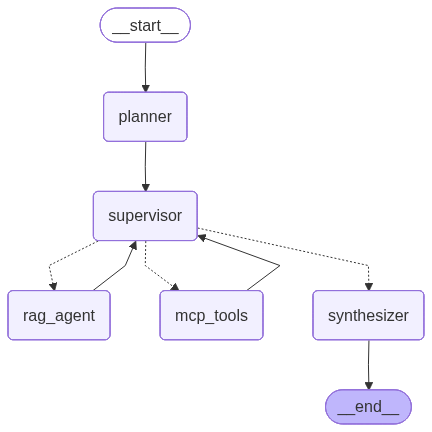

In [5]:
# Visualize the compiled graph
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
# Test 1 — retrieval-only query
result = graph.invoke({'messages': [{'role': 'user', 'content': 'What was the net income in 2023?'}]})
print(result['final_answer'])

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
The net income in 2023 was ¥1,107 billion, as reported in the annual report (Source: dbfs:/Volumes/cs4603/default/pa4/annual_report.pdf, page 2).


In [7]:
# Test 2 — computation-only query
result = graph.invoke({'messages': [{'role': 'user', 'content': 'What is 15% of 2.4 billion?'}]})
print(result['final_answer'])

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


C:\Users\yahya\Desktop\cs4603-pa4\agent\graph.py:-1: RuntimeWarning: coroutine 'StructuredTool.ainvoke' was never awaited


To find 15% of 2.4 billion, we first need to understand that 2.4 billion is equal to 2.4e9 (2.4 × 10^9). 

The calculation for 15% of 2.4 billion is as follows:
15% of 2.4 billion = 0.15 * 2.4e9

Using the formula:
Result = 2.4e9 * 0.15
Result = 3.6e+08

Therefore, 15% of 2.4 billion is 3.6e+08, or 360 million.


In [8]:
# Test 3 — combined query (retrieval + computation)
combined_query = 'What was the net revenue in 2023, and what would it be after 10% growth for 3 years?'
result = graph.invoke({'messages': [{'role': 'user', 'content': combined_query}]})
print('Plan:', result['plan'])
print()
print('Step results:')
for r in result['step_results']:
    print(' -', r)
print()
print('Final answer:')
print(result['final_answer'])

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


C:\Users\yahya\Desktop\cs4603-pa4\agent\graph.py:-1: RuntimeWarning: coroutine 'StructuredTool.ainvoke' was never awaited
C:\Users\yahya\Desktop\cs4603-pa4\agent\graph.py:-1: RuntimeWarning: coroutine 'StructuredTool.ainvoke' was never awaited


Plan: ['Find net revenue for fiscal year 2023 from the annual report', 'Calculate 10% annual growth rate: 1 + 0.10', 'Calculate compound growth: net revenue * (1.10)^3']

Step results:
 - Step 1 (retrieval): ¥16,910 billion (source: dbfs:/Volumes/cs4603/default/pa4/annual_report.pdf)
 - Step 2 (calculation): [{'type': 'text', 'text': '1 + 0.10 = 1.1', 'id': 'lc_1342cf73-9ac5-4a7c-9ab5-2ed46c12966c'}]
 - Step 3 (calculation): [{'type': 'text', 'text': "Error evaluating 'net revenue * (1.10)^3': invalid syntax (<unknown>, line 1)", 'id': 'lc_592c526a-e702-4ed9-808f-4c3f60520132'}]

Final answer:
To find the net revenue in 2023 and after 10% growth for 3 years, we follow these steps:

1. The net revenue in 2023 is given as ¥16,910 billion.
2. The growth factor for 10% growth is calculated as 1 + 0.10 = 1.1.
3. To find the net revenue after 10% growth for 3 years, we apply the formula: net revenue * (1.10)^3.

Given the initial net revenue is ¥16,910 billion, we calculate the future net re

In [9]:
# Step-by-step execution trace for the combined query
print('=== EXECUTION TRACE ===')
for step in graph.stream({'messages': [{'role': 'user', 'content': combined_query}]}):
    node_name = list(step.keys())[0]
    node_out = step[node_name]
    print(f'\n[{node_name}]')
    for k, v in node_out.items():
        if k != 'messages':
            print(f'  {k}: {v}')

=== EXECUTION TRACE ===

[planner]
  plan: ['Find net revenue for fiscal year 2023 from the annual report', 'Calculate 10% annual growth rate: 1 + 0.10', 'Calculate compound growth: net revenue * (1.10)^3']
  current_step_index: 0
  step_results: []

[supervisor]
  next_agent: rag_agent
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.

[rag_agent]
  step_results: ['Step 1 (retrieval): ¥16,910 billion (source: dbfs:/Volumes/cs4603/default/pa4/annual_report.pdf)']
  current_step_index: 1

[supervisor]
  next_agent: mcp_tools


C:\Users\yahya\Desktop\cs4603-pa4\agent\graph.py:-1: RuntimeWarning: coroutine 'StructuredTool.ainvoke' was never awaited



[mcp_tools]
  step_results: ['Step 1 (retrieval): ¥16,910 billion (source: dbfs:/Volumes/cs4603/default/pa4/annual_report.pdf)', "Step 2 (calculation): [{'type': 'text', 'text': '1 + 0.10 = 1.1', 'id': 'lc_ccff14e0-71fd-42e2-8b80-fc8d247068c4'}]"]
  current_step_index: 2

[supervisor]
  next_agent: mcp_tools


C:\Users\yahya\Desktop\cs4603-pa4\agent\graph.py:-1: RuntimeWarning: coroutine 'StructuredTool.ainvoke' was never awaited



[mcp_tools]
  step_results: ['Step 1 (retrieval): ¥16,910 billion (source: dbfs:/Volumes/cs4603/default/pa4/annual_report.pdf)', "Step 2 (calculation): [{'type': 'text', 'text': '1 + 0.10 = 1.1', 'id': 'lc_ccff14e0-71fd-42e2-8b80-fc8d247068c4'}]", 'Step 3 (calculation): [{\'type\': \'text\', \'text\': "Error evaluating \'net revenue * (1.10)^3\': invalid syntax (<unknown>, line 1)", \'id\': \'lc_e3a5db81-bfbe-42ea-a2d9-8e9f61583500\'}]']
  current_step_index: 3

[supervisor]
  next_agent: synthesizer

[synthesizer]
  final_answer: To find the net revenue in 2023 and after 10% growth for 3 years, we follow these steps:

1. **Identify the original net revenue**: The net revenue in 2023 was ¥16,910 billion, as per the annual report (source: dbfs:/Volumes/cs4603/default/pa4/annual_report.pdf).

2. **Calculate the growth factor**: A 10% growth rate means that each year, the revenue is multiplied by 1.10 (since 100% + 10% = 110%, or 1.10 as a factor). The calculation for the growth factor o

## Part 2: Databricks Deployment

### Task 2.2 + 2.3 — Log, Register, and Deploy

Run from terminal: `uv run python deployment/deploy.py`
deployed through vscode

### Task 2.4 — Test the Deployed Endpoint

Run after the endpoint reaches READY state in the Serving UI.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

DATABRICKS_HOST  = os.environ['DATABRICKS_HOST']
DATABRICKS_TOKEN = os.environ['DATABRICKS_TOKEN']
ENDPOINT_NAME    = os.environ.get('SERVING_ENDPOINT_NAME', 'yahya-document-analyst')

In [2]:
# Call via curl (subprocess)
import subprocess, json

payload = json.dumps({'messages': [{'role': 'user', 'content': 'What was the net income in 2023?'}]})
cmd = [
    'curl', '-s', '-X', 'POST',
    f'{DATABRICKS_HOST}/serving-endpoints/{ENDPOINT_NAME}/invocations',
    '-H', 'Content-Type: application/json',
    '-H', f'Authorization: Bearer {DATABRICKS_TOKEN}',
    '-d', payload,
]
out = subprocess.run(cmd, capture_output=True, text=True)
print(out.stdout[:2000])

{"choices": [{"message": {"role": "assistant", "content": "The net income in 2023 was \u00a51,107 billion, as reported in the annual report (Source: dbfs:/Volumes/cs4603/default/pa4/annual_report.pdf)."}, "index": 0, "finish_reason": "stop"}], "object": "chat.completion", "created": 1784060194}


In [3]:
# Call via OpenAI SDK
import openai

client = openai.OpenAI(
    api_key=DATABRICKS_TOKEN,
    base_url=f'{DATABRICKS_HOST}/serving-endpoints',
)

test_queries = [
    'What was the net income in 2023?',
    'What is 15% of 2.4 billion?',
    'What was the net revenue in 2023, and what would it be after 10% growth for 3 years?',
]

for q in test_queries:
    print(f'Q: {q}')
    import time
    t0 = time.time()
    resp = client.chat.completions.create(
        model=ENDPOINT_NAME,
        messages=[{'role': 'user', 'content': q}],
    )
    latency = time.time() - t0
    print(f'A: {resp.choices[0].message.content}')
    print(f'Latency: {latency:.1f}s\n')

Q: What was the net income in 2023?
A: The net income in 2023 was ¥1,107 billion, as reported in the annual report (Source: dbfs:/Volumes/cs4603/default/pa4/annual_report.pdf).
Latency: 6.2s

Q: What is 15% of 2.4 billion?
A: To find 15% of 2.4 billion, we first acknowledge that the specific value of 2.4 billion was not found in the document as per Step 1. However, for the purpose of calculation, we will proceed with the given numerical value.

Given that 2.4 billion can be represented as 2.4e9 (2.4 * 10^9), we calculate 15% of this value. 

The calculation, as shown in Step 2, is: 2.4e9 * 0.15 = 3.6e+08.

This result translates to 3.6 * 10^8, or 360 million.

Therefore, 15% of 2.4 billion is 360 million.
Latency: 7.3s

Q: What was the net revenue in 2023, and what would it be after 10% growth for 3 years?
A: To find the net revenue in 2023 and after 10% growth for 3 years, we need to follow these steps:

1. Identify the original net revenue in 2023: According to the annual report (sou

## Part 3: Python Client SDK

### Task 3.2 — Demonstrate the Client

In [2]:
from client.sdk import DocumentAnalystClient

analyst = DocumentAnalystClient(endpoint_name=ENDPOINT_NAME)

In [3]:
# Health check
healthy = analyst.health_check()
print(f'Endpoint healthy: {healthy}')
assert healthy, 'Endpoint is not READY'

Endpoint healthy: True


In [4]:
# ask()
answer = analyst.ask('What was the net income in 2023?')
print(answer)

The net income in 2023 was ¥1,107 billion, as reported in the annual report (source: dbfs:/Volumes/cs4603/default/pa4/annual_report.pdf).


In [5]:
# ask_streaming()
print('Streaming response:')
for chunk in analyst.ask_streaming('What was the total revenue in 2023?'):
    print(chunk, end='', flush=True)
print()

Streaming response:
The total revenue in 2023 was ¥16,910 billion (or ¥16.91 trillion), as stated in the annual report (page 2) [1].

Reference:
[1] dbfs:/Volumes/cs4603/default/pa4/annual_report.pdf, page 2.


In [6]:
# Simulate timeout
from client.sdk import DocumentAnalystClient

fast_client = DocumentAnalystClient(endpoint_name=ENDPOINT_NAME, timeout=0.001)
try:
    fast_client.ask('What was the revenue?')
except TimeoutError as e:
    print(f'Caught TimeoutError: {e}')

Caught TimeoutError: Request timed out after 0.001s


In [7]:
# Simulate retry behavior (bad endpoint name triggers retries on 503)
from client.sdk import DocumentAnalystClient, AnalystClientError

bad_client = DocumentAnalystClient(
    endpoint_name='nonexistent-endpoint-xyz',
    max_retries=2,
    timeout=10.0,
)
try:
    bad_client.ask('test')
except (AnalystClientError, Exception) as e:
    print(f'Caught error after retries: {type(e).__name__}: {e}')

Caught error after retries: AnalystClientError: Error code: 404 - {'error_code': 'ENDPOINT_NOT_FOUND', 'message': 'The given endpoint does not exist, please retry after checking the specified model and version deployment exists.'}
